# Exercise 3.1
**Bakker & Post – Analytical Groundwater Modeling, Chapter 3**
##### A.A.Aliyu -  6613535

> *Determine the value of the effective saturated thickness $H$ such that the head at the impermeable boundary is the same for the solutions with variable saturated thickness and constant saturated thickness. Plot the head vs. $x$ for both solutions.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

In [2]:
L  = 1000   # aquifer length (m)
zb = -5     # aquifer bottom elevation (m)
k  = 10     # hydraulic conductivity (m/d)
hL = 4      # head at the river, x = L (m)
N  = 0.001  # areal recharge (m/d)

## Variable-T solution (Eq. 3.13)

Using the discharge potential $\Phi = \tfrac{1}{2}k(h - z_b)^2$, the exact solution for the head is:

$$h(x) = z_b + \sqrt{-\frac{N}{k}(x^2 - L^2) + (h_L - z_b)^2}$$

The head at the impermeable boundary ($x = 0$) is therefore:

$$h(0) = z_b + \sqrt{\frac{NL^2}{k} + (h_L - z_b)^2}$$

In [3]:
x = np.linspace(0, L, 400)

phiL  = 0.5 * k * (hL - zb)**2          # Φ_L  (Eq. 3.11)
phi   = -N / 2 * (x**2 - L**2) + phiL  # Φ(x) (Eq. 3.12)
h_var = zb + np.sqrt(2 * phi / k)       # h(x) (Eq. 3.13)

h0_var = h_var[0]   # head at the impermeable boundary (x = 0)
print(f'Head at x = 0 (variable T): {h0_var:.4f} m')

Head at x = 0 (variable T): 8.4536 m


## Finding H* analytically

The constant-T (Section 1.3) head at $x = 0$ is:

$$h_{\text{const}}(0) = \frac{N L^2}{2 k H^*} + h_L$$

Setting this equal to $h_{\text{var}}(0)$ and solving for $H^*$:

$$\boxed{H^* = \frac{N L^2}{2k\,(h_{\text{var}}(0) - h_L)}}$$

In [7]:
H_star = N * L**2 / (2 * k * (h0_var - hL))
print(f'Effective saturated thickness H* = {H_star:.4f} m')

# Verify: head at x=0 with H*
h0_check = N * L**2 / (2 * k * H_star) + hL
print(f'Verification – constant-T head at x=0 with H*: {h0_check:.4f} m ')

Effective saturated thickness H* = 11.2268 m
Verification – constant-T head at x=0 with H*: 8.4536 m 


## Constant-T solution with H*

$$h_{\text{const}}(x) = -\frac{N}{2kH^*}(x^2 - L^2) + h_L$$

In [5]:
h_const_star = -N / (2 * k * H_star) * (x**2 - L**2) + hL

# Also compute the original H = 10 m approximation for reference
H_orig = 10
h_const_orig = -N / (2 * k * H_orig) * (x**2 - L**2) + hL

## Plot

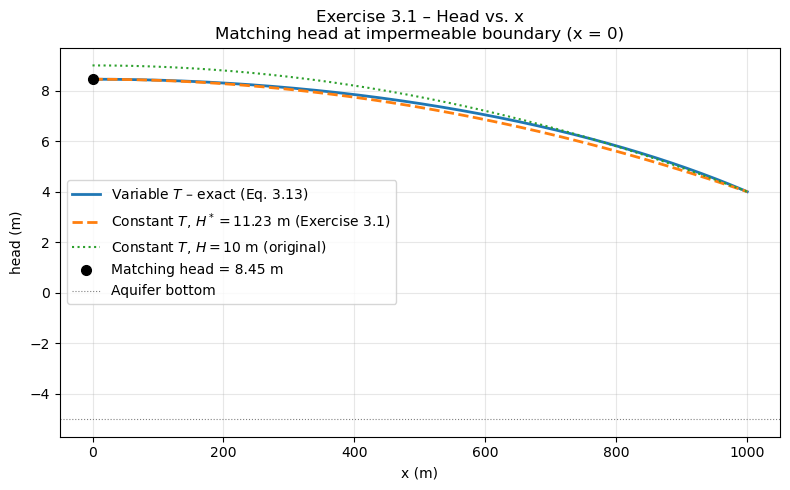


--- Summary ---
H* (effective thickness)           = 11.2268 m
Head at x=0  (variable T)          = 8.4536 m
Head at x=0  (constant T, H*)      = 8.4536 m
Head at x=0  (constant T, H=10 m)  = 9.0000 m
Max difference (variable vs H*)    = 0.2208 m  at x = 742 m


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, h_var,        'C0',   lw=2,  label='Variable $T$ – exact (Eq. 3.13)')
ax.plot(x, h_const_star, 'C1--', lw=2,  label=f'Constant $T$, $H^*={H_star:.2f}$ m (Exercise 3.1)')
ax.plot(x, h_const_orig, 'C2:',  lw=1.5,label=f'Constant $T$, $H={H_orig}$ m (original)')

# Mark the matching point at x = 0
ax.plot(0, h0_var, 'ko', ms=7, zorder=5, label=f'Matching head = {h0_var:.2f} m')

ax.axhline(zb, color='grey', lw=0.8, ls=':', label='Aquifer bottom')
ax.set_xlabel('x (m)')
ax.set_ylabel('head (m)')
ax.set_title('Exercise 3.1 – Head vs. x\nMatching head at impermeable boundary (x = 0)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n--- Summary ---')
print(f'H* (effective thickness)           = {H_star:.4f} m')
print(f'Head at x=0  (variable T)          = {h0_var:.4f} m')
print(f'Head at x=0  (constant T, H*)      = {h_const_star[0]:.4f} m')
print(f'Head at x=0  (constant T, H=10 m)  = {h_const_orig[0]:.4f} m')
print(f'Max difference (variable vs H*)    = {np.max(np.abs(h_var - h_const_star)):.4f} m  at x = {x[np.argmax(np.abs(h_var - h_const_star))]:.0f} m')